In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea
import scipy as sp
%matplotlib inline

In [50]:
pd.set_option('display.max_columns', None)

## Load Dataset

In [51]:
dataset = pd.read_csv("ipl_deliveries.csv")

In [52]:
dataset.head()

,Unnamed: 0,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
2,2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
3,3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
4,4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN


In [53]:
dataset.isna().sum()
delivery_dataset = dataset.copy()

### Filling Missing values

In [54]:
### Filling in missing values: in player_dismissed, dismissal_kind, fielder.

delivery_dataset['player_dismissed'] = delivery_dataset['player_dismissed'].fillna('not out')

delivery_dataset['dismissal_kind'] = delivery_dataset['dismissal_kind'].fillna('N/A')

delivery_dataset['fielder'] = delivery_dataset['fielder'].fillna('N/A')

### Dropping Duplicates

In [55]:
# display(delivery_dataset.loc[delivery_dataset.duplicated().sum()])
print(f"Number of duplicated rows before: {delivery_dataset.duplicated().sum()}")

print(f"Number of duplicated rows after: {delivery_dataset.duplicated().sum()}")

Number of duplicated rows before: 0
Number of duplicated rows after: 0


In [56]:
delivery_dataset.head()

,Unnamed: 0,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,not out,N/A,N/A
1,1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,not out,N/A,N/A
2,2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,not out,N/A,N/A
3,3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,not out,N/A,N/A
4,4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,not out,N/A,N/A


### Standardising Team Names

In [57]:
all_teams = np.unique(delivery_dataset['batting_team'])

print(f"Teams before standardising names: {len(all_teams)}")
display(all_teams)

same_team_names = {
    'Rising Pune Supergiants' : 'Rising Pune Supergiant',
    'Delhi Daredevils' : 'Delhi Capitals',
    'Deccan Chargers' : 'Sunrisers Hyderabad',
    'Kings XI Punjab' : 'Punjab Kings'
}

## Function to standardised team name:
def standardised_team_names(df,columns):
    for col in columns:
        df[col] = df[col].replace(same_team_names)
    return df

team_columns = ['batting_team', 'bowling_team']
delivery_dataset = standardised_team_names(delivery_dataset, team_columns)

all_teams = np.unique(delivery_dataset['batting_team'])
print(f"Teams after standardising names: {len(all_teams)}")
display(all_teams)

Teams before standardising names: 14


array(['Chennai Super Kings', 'Deccan Chargers', 'Delhi Daredevils',
       'Gujarat Lions', 'Kings XI Punjab', 'Kochi Tuskers Kerala',
       'Kolkata Knight Riders', 'Mumbai Indians', 'Pune Warriors',
       'Rajasthan Royals', 'Rising Pune Supergiant',
       'Rising Pune Supergiants', 'Royal Challengers Bangalore',
       'Sunrisers Hyderabad'], dtype=object)

Teams after standardising names: 12


array(['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions',
       'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Mumbai Indians',
       'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Sunrisers Hyderabad'], dtype=object)

### Finding the batsman stats first:

Top socring batsman, most dismissed batsman, batsman total balls, 
strike rate, total_dismissals, batting average, batsman fours and sixes,
boundary %tage, runs per match, count hundreds, count fifties, strike rate. 

In [58]:
batsman_team = delivery_dataset.groupby('batsman')['batting_team'].unique()

In [59]:
# Finding the batsman stats first:
# batsman total balls balls
batsman_total_balls = delivery_dataset['batsman'].value_counts().reset_index()
batsman_total_balls.rename(columns={'count':'no.of_balls'}, inplace=True)


# batsman runs
batsman_runs = delivery_dataset.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).reset_index()


#making a new df for batsman and will use this for eda!
batsman_stats = pd.merge(batsman_runs, batsman_total_balls, on='batsman', how='left')


# batsman dismissals
batsman_dismissals = delivery_dataset['player_dismissed'].value_counts().reset_index()
batsman_dismissals.columns = ['batsman', 'dismissals_count']
batsman_dismissals = batsman_dismissals[batsman_dismissals['batsman'] != 'not out']
# merging:
batsman_stats = pd.merge(batsman_stats, batsman_dismissals, on='batsman', how='left')
batsman_stats['dismissals_count'] = batsman_stats['dismissals_count'].fillna(0)


#strike rate
batsman_stats['strike_rate'] = (batsman_stats['batsman_runs'] / batsman_stats['no.of_balls'].replace(0,np.nan)) * 100
batsman_stats['strike_rate'] = batsman_stats['strike_rate'].fillna(np.inf)


# batting average
batsman_stats['batting_average'] = batsman_stats['batsman_runs'] / batsman_stats['dismissals_count'].replace(0,np.nan)
batsman_stats['batting_average'] = batsman_stats['batting_average'].fillna(np.inf)


# batsman and played teams
batsman_stats = pd.merge(batsman_stats, batsman_team, on='batsman', how='left')


# bstsman fours and sixes.
batsman_fours = delivery_dataset[delivery_dataset['batsman_runs'] == 4].groupby('batsman')['batsman_runs'].count().reset_index()
batsman_fours.rename(columns={'batsman_runs':'no_of_fours'}, inplace=True)

batsman_sixes= delivery_dataset[delivery_dataset['batsman_runs'] == 6].groupby('batsman')['batsman_runs'].count().reset_index()
batsman_sixes.rename(columns={'batsman_runs':'no_of_sixes'}, inplace=True)

batsman_stats = pd.merge(batsman_stats, batsman_fours, on='batsman', how='left')
batsman_stats = pd.merge(batsman_stats, batsman_sixes, on='batsman', how='left')

batsman_stats['no_of_fours'] = batsman_stats['no_of_fours'].fillna(0).astype(int)
batsman_stats['no_of_sixes'] = batsman_stats['no_of_sixes'].fillna(0).astype(int)


# boundary percentage
batsman_stats['boundary_percentage'] = (
    ((batsman_stats['no_of_fours'] * 4) + (batsman_stats['no_of_sixes'] * 6)) / batsman_stats['batsman_runs'].replace(0,np.nan)) * 100

batsman_stats['boundary_percentage'] = batsman_stats['boundary_percentage'].fillna(0)


##batsman_runs_per_match
batsman_runs_per_match = delivery_dataset.groupby(['match_id','batsman'])['batsman_runs'].sum().reset_index()

def count_hundreds(runs):
    return (runs>=100).sum()

def count_fifties(runs):
    return (runs>=50).sum()

hundreds = batsman_runs_per_match.groupby('batsman')['batsman_runs'].apply(count_hundreds).reset_index(name='no_of_100s')
fifties = batsman_runs_per_match.groupby('batsman')['batsman_runs'].apply(count_fifties).reset_index(name='no_of_50s')

batsman_stats = pd.merge(batsman_stats, hundreds, on='batsman', how='left')
batsman_stats = pd.merge(batsman_stats, fifties, on='batsman', how='left')

batsman_stats['no_of_100s']= batsman_stats['no_of_100s'].fillna(0).astype(int)
batsman_stats['no_of_50s']= batsman_stats['no_of_50s'].fillna(0).astype(int)

In [60]:
batsman_stats

,batsman,batsman_runs,no.of_balls,dismissals_count,strike_rate,batting_average,batting_team,no_of_fours,no_of_sixes,boundary_percentage,no_of_100s,no_of_50s
0,SK Raina,4548,3369,134.0,134.995548,33.940299,"[Gujarat Lions, Chennai Super Kings]",402,174,58.311346,1,32
1,V Kohli,4423,3494,118.0,126.588437,37.483051,[Royal Challengers Bangalore],384,160,56.432286,4,35
2,RG Sharma,4207,3274,129.0,128.497251,32.612403,"[Mumbai Indians, Sunrisers Hyderabad]",354,173,58.331353,1,33
3,G Gambhir,4132,3433,131.0,120.361200,31.541985,"[Kolkata Knight Riders, Delhi Capitals]",484,58,55.275895,0,35
4,DA Warner,4014,2902,100.0,138.318401,40.140000,"[Sunrisers Hyderabad, Delhi Capitals]",401,160,63.876432,3,39
...,...,...,...,...,...,...,...,...,...,...,...,...
456,Abdur Razzak,0,2,0.0,0.000000,inf,[Royal Challengers Bangalore],0,0,0.000000,0,0
457,S Kaushik,0,1,1.0,0.000000,0.000000,[Gujarat Lions],0,0,0.000000,0,0
458,S Ladda,0,10,1.0,0.000000,0.000000,[Delhi Capitals],0,0,0.000000,0,0
459,U Kaul,0,1,0.0,0.000000,inf,[Punjab Kings],0,0,0.000000,0,0


### Bowler Stats

Finding the bowler stats:
bowler who bowled most balls, most run giving bowler(conceeded), most_wide, most_no balls, bye runs, legbye runs, penalty runs, extra runs overall.
 bowler credited dismisalls, wicket by bowlers, bpowling avg, matches_played by bowler,no.of balls bowled, total_overs, dot balls, wickets pers match, 4 wicket haul and 5 wicket haul, 
bowling_economy, avg dot balls, bowling_SR, 


In [61]:
#balls bowled by bowler
total_balls_bowled = delivery_dataset['bowler'].value_counts().reset_index()
total_balls_bowled.rename(columns={'count':'balls bowled'},inplace=True)
#total runs conceeded
total_runs_conceeded_by_bowler = delivery_dataset.groupby('bowler')['total_runs'].sum().sort_values(ascending=False).reset_index()
total_runs_conceeded_by_bowler.rename(columns={'total_runs':'runs_conceded'}, inplace=True)

#bowler stats
bowler_stats = pd.merge(total_runs_conceeded_by_bowler,total_balls_bowled,on='bowler', how='left')


# most wides
bowled_most_wide = delivery_dataset.groupby('bowler')['wide_runs'].sum().sort_values(ascending= False).reset_index()
bowled_most_wide.rename(columns={'count':'wide balls'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, bowled_most_wide, on='bowler', how='left'))

# most no balls
bowled_most_no_balls = delivery_dataset.groupby('bowler')['noball_runs'].sum().sort_values(ascending= False).reset_index()
bowled_most_wide.rename(columns={'count':'no balls'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, bowled_most_no_balls, on='bowler', how='left'))

#most bye runs
bowled_most_by_runs = delivery_dataset.groupby('bowler')['bye_runs'].sum().sort_values(ascending= False).reset_index()
bowled_most_wide.rename(columns={'count':'bye runs'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats,bowled_most_by_runs , on='bowler', how='left'))

# most leg bye
bowled_most_leg_bye = delivery_dataset.groupby('bowler')['legbye_runs'].sum().sort_values(ascending= False).reset_index()
bowled_most_wide.rename(columns={'count':'leg bye runs'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, bowled_most_leg_bye , on='bowler', how='left'))

# most penalty runs
bowled_most_penalty_runs = delivery_dataset.groupby('bowler')['penalty_runs'].sum().sort_values(ascending=False).reset_index()
bowled_most_wide.rename(columns={'count':'penalty runs'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, bowled_most_penalty_runs , on='bowler', how='left'))

# msot extra runs overall
bowled_extra_runs = delivery_dataset.groupby('bowler')['extra_runs'].sum().sort_values(ascending=False).reset_index()
bowled_most_wide.rename(columns={'count':'extra runs'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats,bowled_extra_runs , on='bowler', how='left'))

#bowler credited wickets
bowler_credited_dismissal = delivery_dataset[
    delivery_dataset['dismissal_kind'].isin(['caught', 'bowled', 'lbw' ,'stumped', 'caught and bowled'])
]

wickets_by_bowler = bowler_credited_dismissal.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False)
wickets_by_bowler = wickets_by_bowler.reset_index()
wickets_by_bowler.rename(columns= {'dismissal_kind':'no_of_wickets'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, wickets_by_bowler, on='bowler', how='left'))

# Bowler stats: bowling_avg, totalmatches, total overs, total dot balls, wicket per match (matchid), four wickets, five wickets, 
# bowling economy, avg  dot balls, bowling SR 
bowler_stats['bowling_average'] = bowler_stats['runs_conceded'] / bowler_stats['no_of_wickets'].replace(0,np.nan)
bowler_stats['bowling_average'] = bowler_stats['bowling_average'].fillna(0)

#total matches played.
total_matches_played_by_bowler = delivery_dataset.groupby('bowler')['match_id'].nunique()
bowler_stats = pd.merge(bowler_stats, total_matches_played_by_bowler,on='bowler', how='left')
bowler_stats.rename(columns={'match_id':'matches_played'},inplace=True)

#total overs
total_overs = delivery_dataset.groupby('bowler')['over'].nunique().reset_index()
total_overs.rename(columns={'over':'no_of_overs'}, inplace=True)
bowler_stats = pd.merge(bowler_stats, total_overs, on='bowler', how='left')

# #total dot balls
total_dot_balls= delivery_dataset[delivery_dataset['total_runs'] == 0].groupby('bowler')['total_runs'].value_counts().reset_index()
total_dot_balls.rename(columns={'count':'dot balls'},inplace=True)
bowler_stats = pd.merge(bowler_stats, total_dot_balls, on='bowler',how='left')
bowler_stats.drop(columns=['total_runs'],axis=1)

# #bowler wickets per match  
bowler_wickets_per_match = bowler_credited_dismissal.groupby(['match_id','bowler'])['dismissal_kind'].count().reset_index()
bowler_wickets_per_match.rename(columns={'dismissal_kind':'wickets_in_match'},inplace=True)


# #4 and 5 wickets haul
four_wicks_haul = bowler_wickets_per_match[bowler_wickets_per_match['wickets_in_match'] >= 4].groupby('bowler')['match_id'].count().reset_index(name='four_plus_wickets')
five_wicks_haul = bowler_wickets_per_match[bowler_wickets_per_match['wickets_in_match'] >= 5].groupby('bowler')['match_id'].count().reset_index(name='five_plus_wickets')
bowler_stats = pd.merge(bowler_stats,four_wicks_haul,on='bowler', how='left')
bowler_stats = pd.merge(bowler_stats,five_wicks_haul,on='bowler', how='left')

bowler_stats['four_plus_wickets'] = bowler_stats['four_plus_wickets'].fillna(0).astype(int)
bowler_stats['five_plus_wickets'] = bowler_stats['five_plus_wickets'].fillna(0).astype(int)


# bowline_economy
bowler_stats['bowling_economy'] = bowler_stats['runs_conceded'] / bowler_stats['no_of_overs'].replace(0,np.nan)
bowler_stats['bowling_economy'] = bowler_stats['bowling_economy'].fillna(np.inf)

#avg dot balls
bowler_stats['average_dot_balls'] = ((bowler_stats['dot balls']/bowler_stats['balls bowled']) * 100).replace(0,np.nan)
bowler_stats['average_dot_balls'] = bowler_stats['average_dot_balls'].fillna(np.inf)

#bowling strike rate
bowler_stats['bowling_strike_rate'] = bowler_stats['balls bowled'] / bowler_stats['no_of_wickets'].replace(0, np.nan)
bowler_stats['bowling_strike_rate'] = bowler_stats['bowling_strike_rate'].fillna(np.inf)

In [62]:
bowler_stats.head(20)

,bowler,runs_conceded,balls bowled,wide_runs,noball_runs,bye_runs,legbye_runs,penalty_runs,extra_runs,no_of_wickets,bowling_average,matches_played,no_of_overs,total_runs,dot balls,four_plus_wickets,five_plus_wickets,bowling_economy,average_dot_balls,bowling_strike_rate
0,Harbhajan Singh,3453,2989,87,3,13,55,0,158,126.0,27.404762,134,20,0.0,1062.0,2,1,172.650000,35.530278,23.722222
1,P Kumar,3342,2637,144,1,5,86,0,236,90.0,37.133333,119,20,0.0,1075.0,0,0,167.100000,40.766022,29.300000
2,PP Chawla,3315,2594,62,1,16,38,0,117,126.0,26.309524,128,19,0.0,910.0,2,0,174.473684,35.080956,20.587302
3,A Mishra,3305,2703,50,20,6,38,0,114,134.0,24.664179,126,20,0.0,953.0,4,1,165.250000,35.257122,20.171642
4,SL Malinga,3034,2694,143,18,22,80,5,268,154.0,19.701299,110,20,0.0,1060.0,5,1,151.700000,39.346696,17.493506
5,R Vinay Kumar,2976,2161,49,10,7,48,0,114,103.0,28.893204,102,20,0.0,755.0,1,0,148.800000,34.937529,20.980583
6,Z Khan,2860,2276,89,2,14,64,0,169,102.0,28.039216,99,20,0.0,873.0,1,0,143.000000,38.356766,22.313725
7,DJ Bravo,2815,2110,93,4,3,57,0,157,122.0,23.073770,103,19,0.0,669.0,2,0,148.157895,31.706161,17.295082
8,UT Yadav,2802,2033,90,16,16,64,0,186,91.0,30.791209,93,20,0.0,713.0,2,0,140.100000,35.071323,22.340659
9,IK Pathan,2711,2113,79,1,21,41,0,142,80.0,33.887500,101,20,0.0,835.0,0,0,135.550000,39.517274,26.412500


In [63]:
dismissal_kinds_frequency = delivery_dataset['dismissal_kind'].value_counts().sort_values(ascending=False)
dismissal_kinds_frequency == dismissal_kinds_frequency[dismissal_kinds_frequency != 'N/A']


## Fielder caught most
fielder_who_caught_most_balls = delivery_dataset['fielder'].value_counts().reset_index()
fielder_who_caught_most_balls = fielder_who_caught_most_balls[fielder_who_caught_most_balls['fielder'] !='N/A']

display(fielder_who_caught_most_balls)

## Teams and extra runs
teams_extra_runs = delivery_dataset.groupby('bowling_team')['extra_runs'].sum().sort_values()

## Matchup Countsabs
all_matchups = delivery_dataset[['batting_team','bowling_team']].value_counts().reset_index()
all_matchups['Matchups'] = all_matchups['batting_team'].astype(str) + ' ' + 'v/s '  + all_matchups['bowling_team'].astype(str)
all_matchups.drop(columns=['batting_team','bowling_team'],inplace=True)
display(all_matchups)

,fielder,count
1,KD Karthik,127
2,MS Dhoni,126
3,RV Uthappa,115
4,AB de Villiers,101
5,SK Raina,96
...,...,...
447,Sunny Singh,1
448,R Ninan,1
449,MD Mishra,1
450,AA Bilakhia,1


,count,Matchups
0,2685,Chennai Super Kings v/s Mumbai Indians
1,2662,Mumbai Indians v/s Chennai Super Kings
2,2590,Punjab Kings v/s Kolkata Knight Riders
3,2574,Royal Challengers Bangalore v/s Mumbai Indians
4,2556,Mumbai Indians v/s Royal Challengers Bangalore
...,...,...
111,123,Kochi Tuskers Kerala v/s Pune Warriors
112,123,Pune Warriors v/s Kochi Tuskers Kerala
113,121,Kochi Tuskers Kerala v/s Mumbai Indians
114,118,Punjab Kings v/s Kochi Tuskers Kerala


In [64]:
# bowler_stats.to_csv('bowler_stats.csv')
# batsman_stats.to_csv('batsman_stats.csv')

## Bowler Performance Analysis

Analysing the `bowler_stats.csv` in detail.

In [65]:
df = pd.read_csv('bowler_stats.csv')

display(df.shape)
display(df.info())


(356, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           356 non-null    int64  
 1   bowler               356 non-null    object 
 2   runs_conceded        356 non-null    int64  
 3   balls bowled         356 non-null    int64  
 4   wide_runs            356 non-null    int64  
 5   noball_runs          356 non-null    int64  
 6   bye_runs             356 non-null    int64  
 7   legbye_runs          356 non-null    int64  
 8   penalty_runs         356 non-null    int64  
 9   extra_runs           356 non-null    int64  
 10  no_of_wickets        310 non-null    float64
 11  bowling_average      356 non-null    float64
 12  matches_played       356 non-null    int64  
 13  no_of_overs          356 non-null    int64  
 14  total_runs           347 non-null    float64
 15  dot balls            347 non-null    flo

None

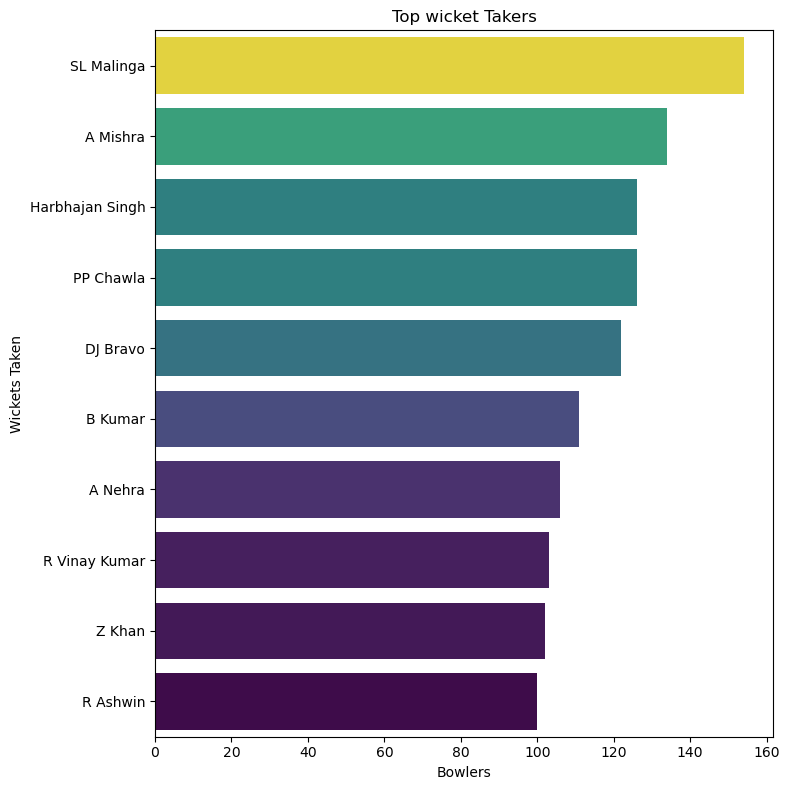

In [66]:
## 1. Who are top wicket takers in IPL.

top_wicket_taking_bowlers = df.sort_values(by='no_of_wickets', ascending=False)
# display(top_10_bowlers)

plt.figure(figsize=(8,8))
sea.barplot(x = 'no_of_wickets',y='bowler', data=top_10_bowlers.head(10), hue='no_of_wickets', palette='viridis', legend=False)
plt.xlabel("Bowlers")
plt.ylabel("Wickets Taken")
plt.title("Top wicket Takers")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Most Economical Bowlers')

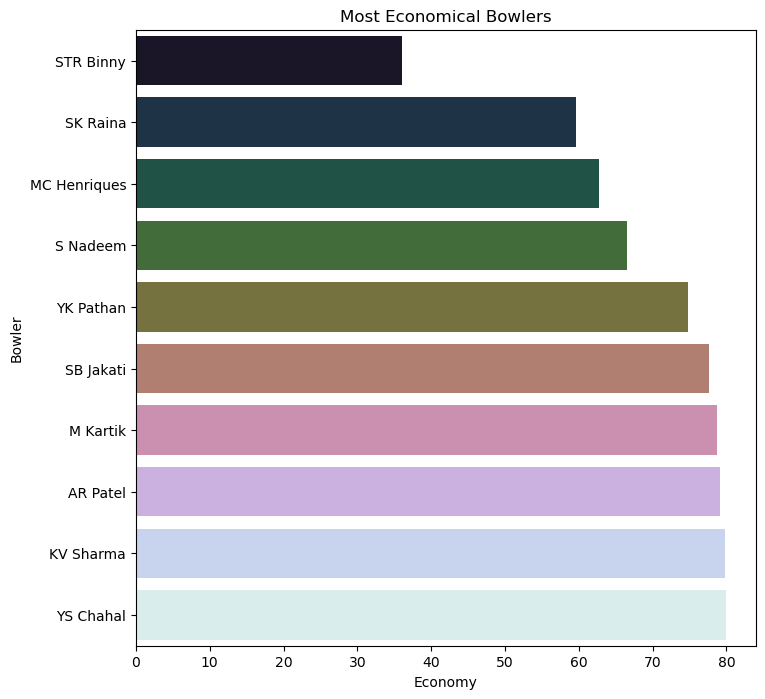

In [67]:
## 2. Who are the most economical bowlers?

top_economical_bowlers = df.sort_values(by='bowling_economy', ascending=True)
top_economical_bowlers = top_economical_bowlers[top_economical_bowlers['matches_played'] >50]
plt.figure(figsize=(8,8))
sea.barplot(x='bowling_economy', y='bowler', hue='bowler', data= top_economical_bowlers.head(10), palette='cubehelix',legend=False)    
plt.xlabel("Economy")
plt.ylabel("Bowler")
plt.title("Most Economical Bowlers")


            

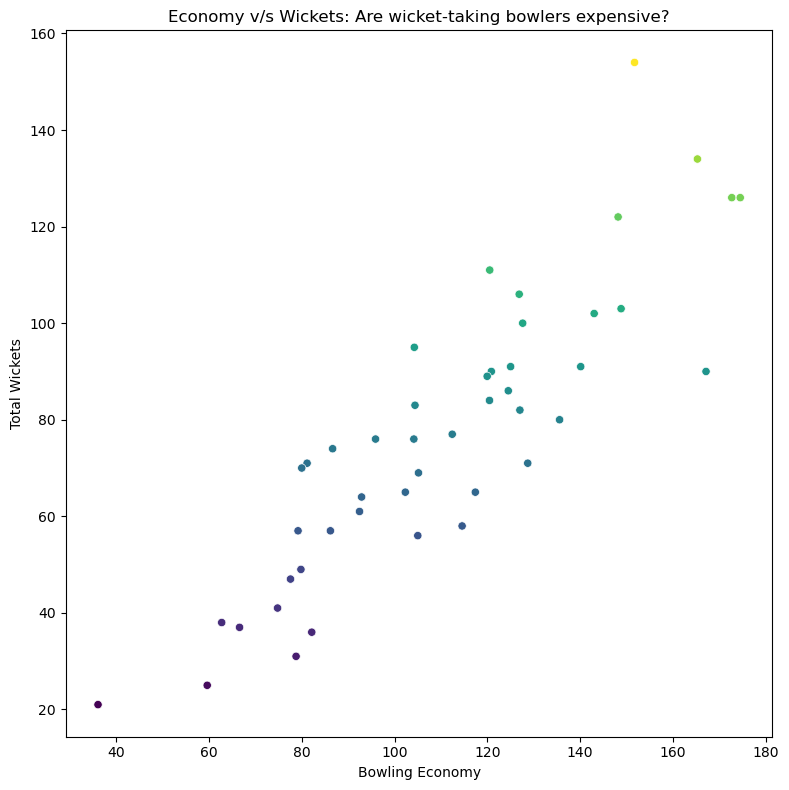

In [72]:
 # Q3. Are the wicket taking bowlers expensive?
data_for_plot = df[df['matches_played'] >= 50]
plt.figure(figsize=(8,8))
sea.scatterplot(data= data_for_plot, x='bowling_economy', y='no_of_wickets', hue='no_of_wickets',palette='viridis', legend=False)
plt.title("Economy v/s Wickets: Are wicket-taking bowlers expensive?")
plt.xlabel("Bowling Economy")
plt.ylabel("Total Wickets")
plt.tight_layout()
plt.show()



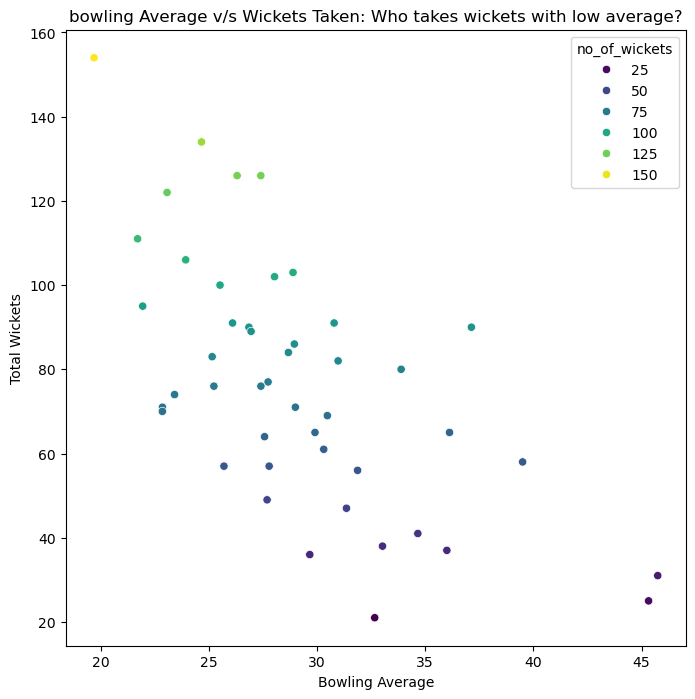

In [73]:
# Q4. Who are the most consistent bowlers.
data_for_plot = df[df['matches_played'] >= 50]
plt.figure(figsize=(8,8))
sea.scatterplot(data=data_for_plot, x='bowling_average', y='no_of_wickets', hue='no_of_wickets', palette='viridis', legend=True)
plt.xlabel("Bowling Average")
plt.ylabel("Total Wickets")
plt.title("bowling Average v/s Wickets Taken: Who takes wickets with low average?")
plt.show()

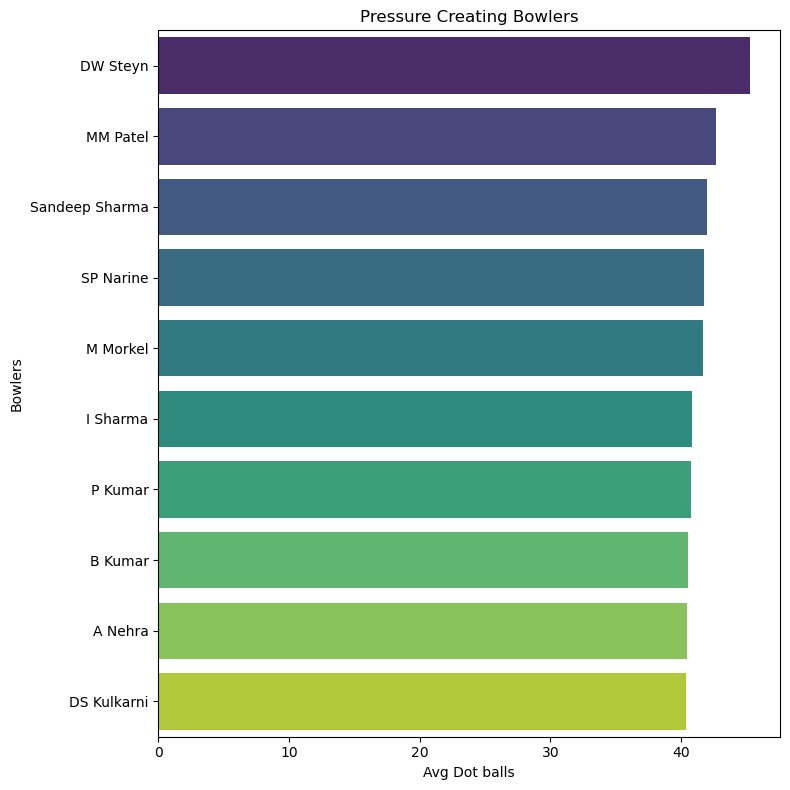

In [74]:
# Q5. Who creates most pressure?
data_for_plot = df[df['matches_played'] >= 50].sort_values(by='average_dot_balls', ascending=False)
plt.figure(figsize=(8,8))
sea.barplot(data=data_for_plot.head(10), x='average_dot_balls', y='bowler', hue='bowler', legend=False, palette='viridis')
plt.title("Pressure Creating Bowlers")
plt.xlabel("Avg Dot balls")
plt.ylabel("Bowlers")
plt.tight_layout()
plt.show()



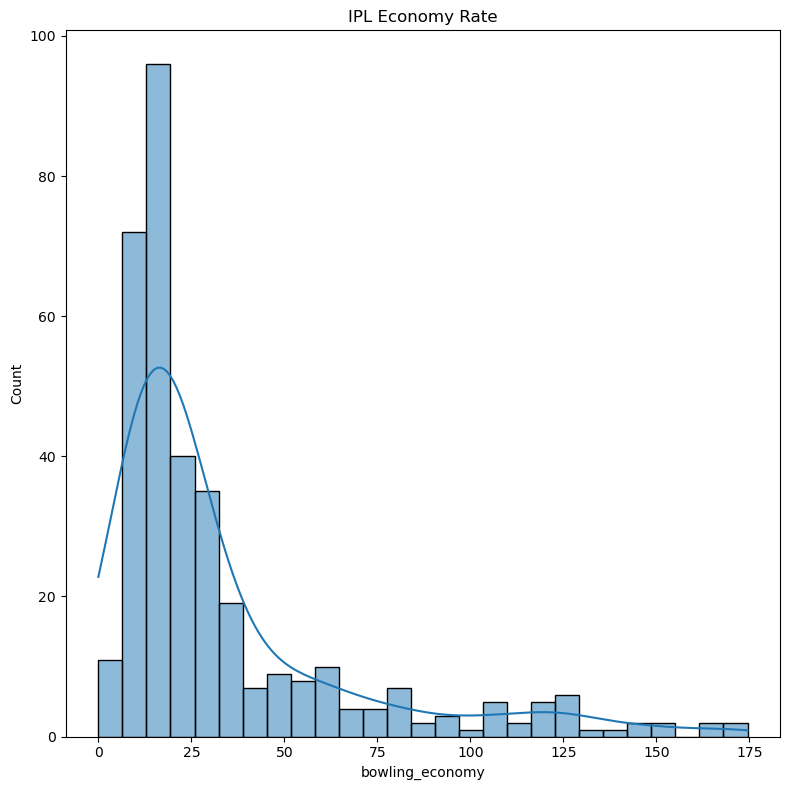

In [75]:
# Q6. Distribution of bowling economy

plt.figure(figsize=(8,8))
sea.histplot(data=df, x='bowling_economy', kde=True)
plt.title("IPL Economy Rate")
plt.xlabel("bowling_economy")
plt.tight_layout()
plt.show()

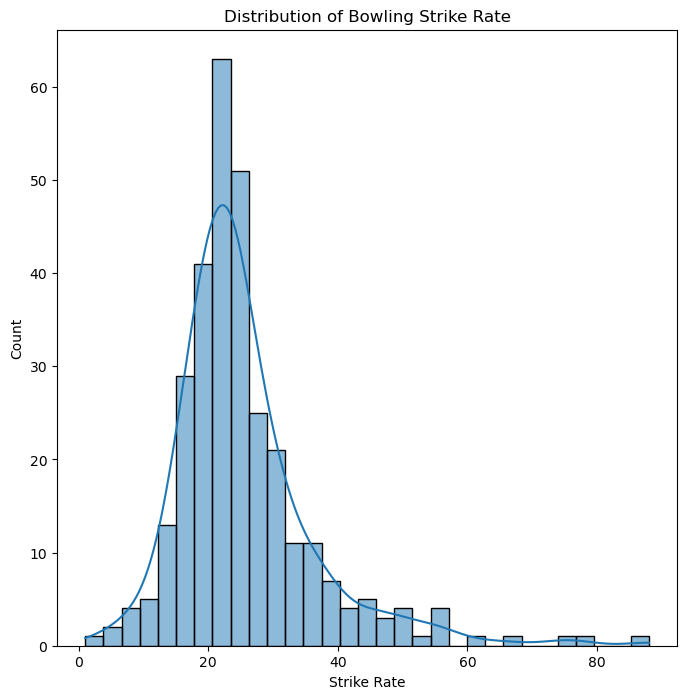

In [77]:
# Q7. Distribution of bowling Strike rate
plt.figure(figsize=(8,8))
sea.histplot(data=df, x='bowling_strike_rate',kde=True)
plt.title("Distribution of Bowling Strike Rate")
plt.xlabel("Strike Rate")
plt.show()

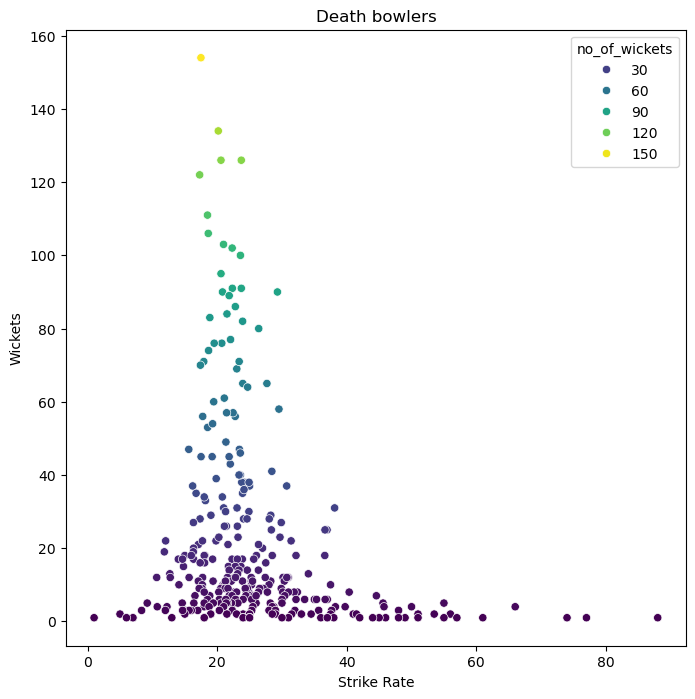

In [79]:
# Q8. Who are the best death/strike bowlers

plt.figure(figsize=(8,8))
sea.scatterplot(data=df, x='bowling_strike_rate', y='no_of_wickets', hue='no_of_wickets', palette='viridis')
plt.title("Death bowlers")
plt.xlabel("Strike Rate")
plt.ylabel("Wickets")
plt.show()

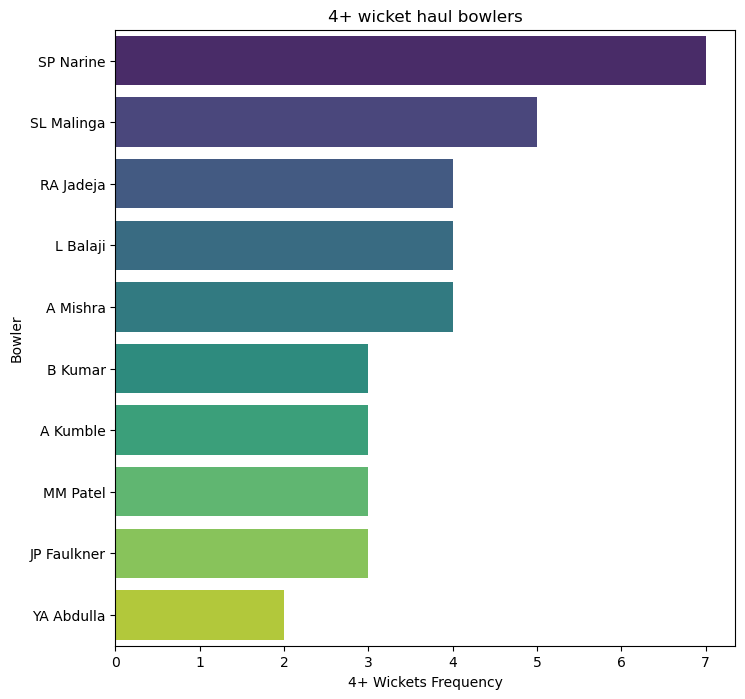

In [82]:
# Q9. Which bowlers take the most 4+ wickets haulabs
plt.figure(figsize=(8,8))
sea.barplot(data=df.sort_values(by='four_plus_wickets', ascending=False).head(10), x='four_plus_wickets',y='bowler',hue='bowler', palette='viridis')
plt.title("4+ wicket haul bowlers")
plt.xlabel("4+ Wickets Frequency")
plt.ylabel("Bowler")
plt.show()

In [91]:
# df.columns

# bowler_score = top_wicket_taking_bowlers[top_wicket_taking_bowlers['matches_played'] >=50]
# bowler_score = bowler_score.sort_values(by='bowling_strike_rate')
# bowler_score = bowler_score.sort_values(by='bowling_economy')
# bowler_score = bowler_score.sort_values(by='average_dot_balls',ascending=False)
# bowler_score = bowler_score.sort_values(by='no_of_wickets', ascending=False)

# bowler_score

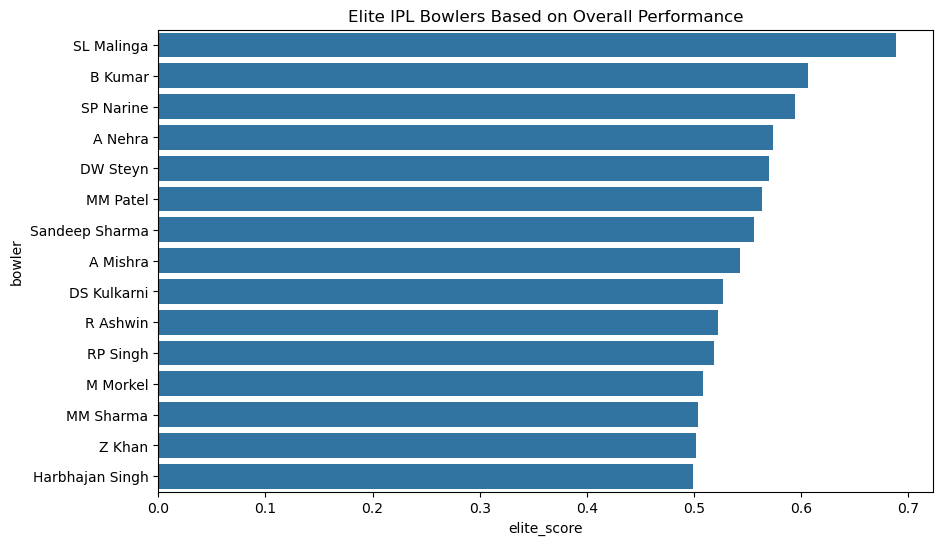

In [96]:
elite_bowlers = df.copy()

elite_bowlers = elite_bowlers[elite_bowlers['matches_played'] >= 50]

## Normalising:abs

elite_bowlers['wicket_score'] = (elite_bowlers['no_of_wickets'] - 
                                 elite_bowlers['no_of_wickets'].min()
                                )/(
                                    elite_bowlers['no_of_wickets'].max() - 
                                    elite_bowlers['no_of_wickets'].min())

elite_bowlers['dot_score'] = (
    elite_bowlers['average_dot_balls'] -
    elite_bowlers['average_dot_balls'].min()
) / (
    elite_bowlers['average_dot_balls'].max() -
    elite_bowlers['average_dot_balls'].min()
)

elite_bowlers['economy_score'] = (
    elite_bowlers['bowling_economy'].max() -
    elite_bowlers['bowling_economy']
) / (
    elite_bowlers['bowling_economy'].max() -
    elite_bowlers['bowling_economy'].min()
)



elite_bowlers['elite_score'] = (
    elite_bowlers['wicket_score'] * 0.5 +
    elite_bowlers['economy_score'] * 0.3 +
    elite_bowlers['dot_score'] * 0.2
)

elite_bowlers = elite_bowlers.sort_values(
    by='elite_score',
    ascending=False
)

elite_bowlers[['bowler','elite_score']].head(15)

plt.figure(figsize=(10,6))

sea.barplot(
    data=elite_bowlers.head(15),
    x='elite_score',
    y='bowler'
)

plt.title("Elite IPL Bowlers Based on Overall Performance")
plt.show()
